In [1]:
suppressMessages(library(ArchR))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(ggplot2))
suppressMessages(library(cowplot))
suppressMessages(library(rtracklayer))

In [2]:
addArchRThreads(threads = 32)

Setting default number of Parallel threads to 32.



In [4]:
out_dir = '../../results/04_single_cell_access_atac/18_find_markers'

# create output directory
if (!dir.exists(out_dir)) {
  dir.create(out_dir, recursive = TRUE)
}

In [5]:
proj <- loadArchRProject("../../results/04_single_cell_access_atac/10_create_archr_project", showLogo = FALSE)

Successfully loaded ArchRProject!



In [6]:
obj <- readRDS("../../results/04_single_cell_access_atac/14_create_seurat/seurat_atac_obj_with_clusters.Rds")

In [7]:
obj

An object of class Seurat 
138953 features across 2024 samples within 1 assay 
Active assay: ATAC (138953 features, 137630 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: lsi, umap_atac

In [8]:
## add clusters to ArchR project
clusters <- obj@meta.data[rownames(proj@cellColData), "seurat_clusters"]

proj <- addCellColData(proj, 
                       data = as.character(clusters), 
                       name = "Clusters", 
                       cells = rownames(proj@cellColData), 
                       force = TRUE)

Overriding previous entry for Clusters



In [9]:
## add UMAP embedding
embedding <- obj@reductions$umap@cell.embeddings
embedding <- embedding[rownames(proj@cellColData), ]

colnames(embedding) <- c("LSI#UMAP_Dimension_1",
                         "LSI#UMAP_Dimension_2")

proj@embeddings[["umap"]] <- SimpleList(df = as.data.frame(embedding),
                                        params = NULL)

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-25f7f75ec6fbf-Date-2026-01-22_Time-18-40-20.673695.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-25f7f75ec6fbf-Date-2026-01-22_Time-18-40-20.673695.log



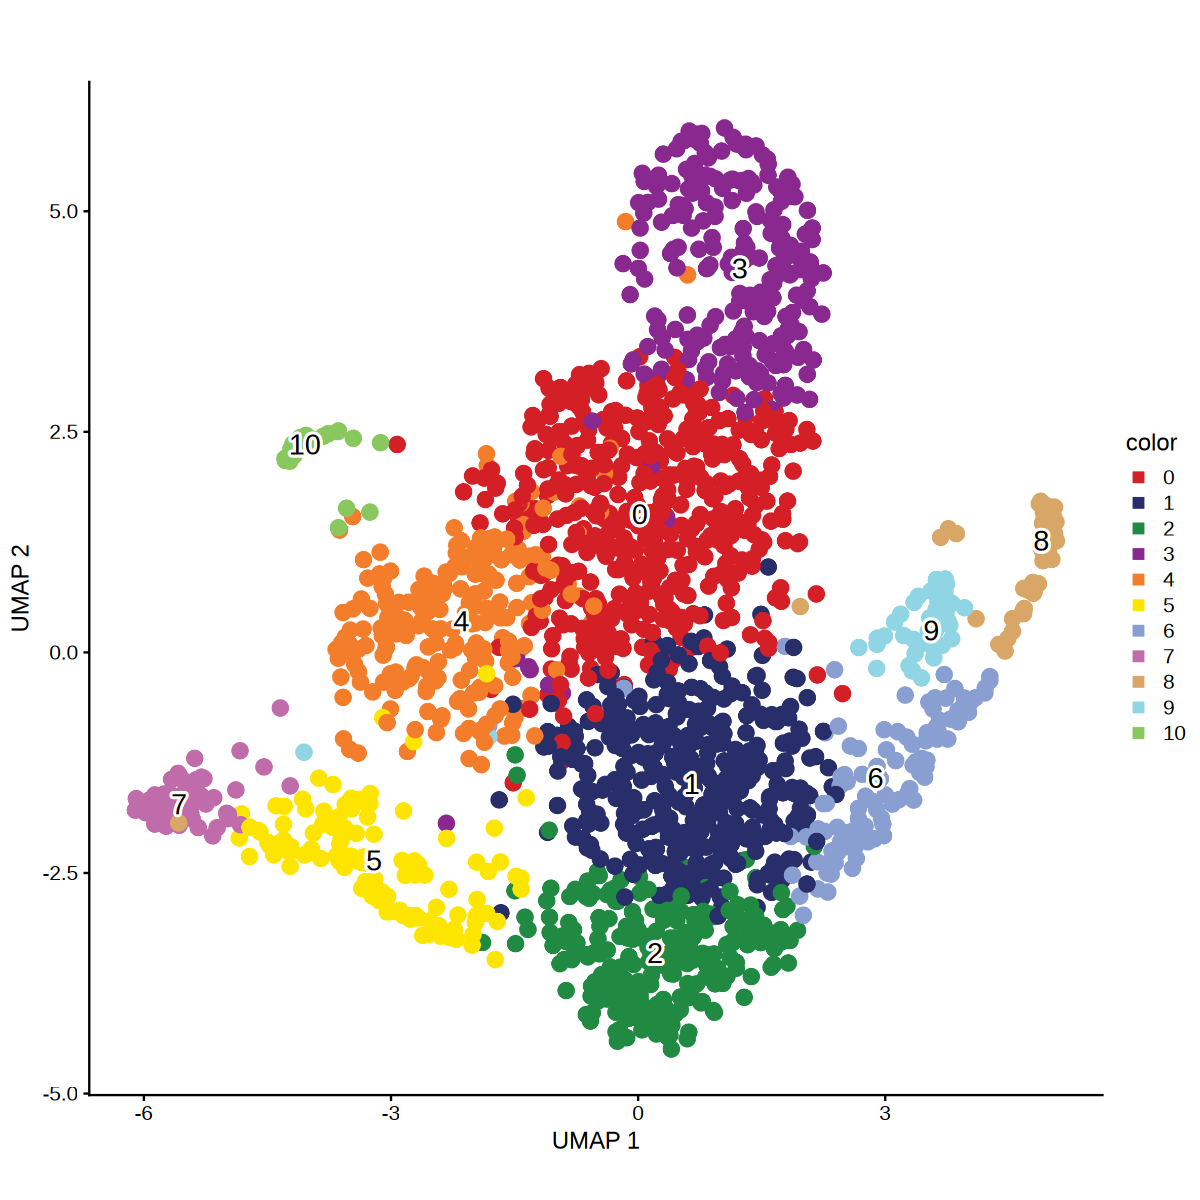

In [11]:
p <- plotEmbedding(ArchRProj = proj,
                   embedding = "umap",
                   colorBy = "cellColData",
                   name = "Clusters",
                   baseSize = 50,
                   size = 3,
                   plotAs = "points",
                  labelSize = 6,
                  labelAsFactors = FALSE) +
    theme_cowplot() +
    xlab("UMAP 1") + ylab("UMAP 2") +
    ggtitle("")

options(repr.plot.height = 10, repr.plot.width = 10)

print(p)

In [12]:
markersGS <- getMarkerFeatures(
    ArchRProj = proj, 
    useMatrix = "GeneScoreMatrix", 
    groupBy = "Clusters",
    bias = c("TSSEnrichment", "log10(nFrags)"),
    testMethod = "wilcoxon"
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-25f7f75e72bc91-Date-2026-01-22_Time-18-40-31.787764.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2026-01-22 18:40:32.263679 : Matching Known Biases, 0.003 mins elapsed.

###########
2026-01-22 18:41:02.48665 : Completed Pairwise Tests, 0.507 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-25f7f75e72bc91-Date-2026-01-22_Time-18-40-31.787764.log



In [15]:
heatmapGS <- plotMarkerHeatmap(
  seMarker = markersGS, 
  cutOff = "FDR <= 0.05 & Log2FC >= 0.1", 
  #labelMarkers = markerGenes,
  transpose = TRUE
)

ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-25f7f79d50c77-Date-2026-01-22_Time-18-47-15.915434.log
If there is an issue, please report to github with logFile!



Printing Top Marker Genes:

0:

	Bpifa1, Selenbp1, Cyp4b1, Scnn1a, Gm28323, 4930434B07Rik, Gm28721, Rgl1, C230024C17Rik, Nvl, Prox1, Gm57154, Mir205hg, Gm48680, Gm36172

1:

	Gm28323, 4930434B07Rik, Gm28721, Rgl1, C230024C17Rik, Nvl, Prox1, Gm57154, Mir205hg, Gm48680, Gm36172, ENSMUSG00000121448, Srgap1, Osbp2, Snap47

2:

	Gm28323, 4930434B07Rik, Gm28721, Rgl1, C230024C17Rik, Nvl, Prox1, Gm57154, Mir205hg, Gm48680, Gm36172, ENSMUSG00000121448, Srgap1, Osbp2, Snap47

3:

	Mir205hg, Nrg2, Bckdhb, Gm28323, 4930434B07Rik, Gm28721, Rgl1, C230024C17Rik, Nvl, Prox1, Gm57154, Gm48680, Gm36172, ENSMUSG00000121448, Srgap1

4:

	Gm28323, 4930434B07Rik, Gm28721, Rgl1, C230024C17Rik, Nvl, Prox1, Gm57154, Mir205hg, Gm48680, Gm36172, ENSMUSG00000121448, Srgap1, Osbp2, Snap47

5:

	Gm28323, 4930434B07Rik, Gm28721, Rgl1, C230024C17Rik, Nvl, Prox1, Gm57154, Mir205hg, Gm48680, Gm36172, ENSMUSG00000121448, Srgap1, Osbp2, Snap47

6:

	Gm28323, 4930434B07Rik, Gm28721, Rgl1, C230024C17Rik, Nvl, Prox1, Gm571

 [1] "Bpifa1"             "Selenbp1"           "Cyp4b1"            
 [4] "Scnn1a"             "Gm28323"            "4930434B07Rik"     
 [7] "Gm28721"            "Rgl1"               "C230024C17Rik"     
[10] "Nvl"                "Prox1"              "Gm57154"           
[13] "Mir205hg"           "Gm48680"            "Gm36172"           
[16] "ENSMUSG00000121448" "Srgap1"             "Osbp2"             
[19] "Snap47"             "Nrg2"               "Bckdhb"            
[22] "Gm31025"            "4930519D14Rik"      "Fgd3"              
[25] "Arhgap22"           "Trac"               "Tnfrsf11b"         
[28] "Atp2a3"             "Gm48187"            "Gm49504"           
[31] "Cdh2"               "Gnat3"              "Jakmip1"           
[34] "Cadps2"             "Dgki"               "9130019P16Rik"     
[37] "Irag2"             


Adding Annotations..

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-25f7f79d50c77-Date-2026-01-22_Time-18-47-15.915434.log



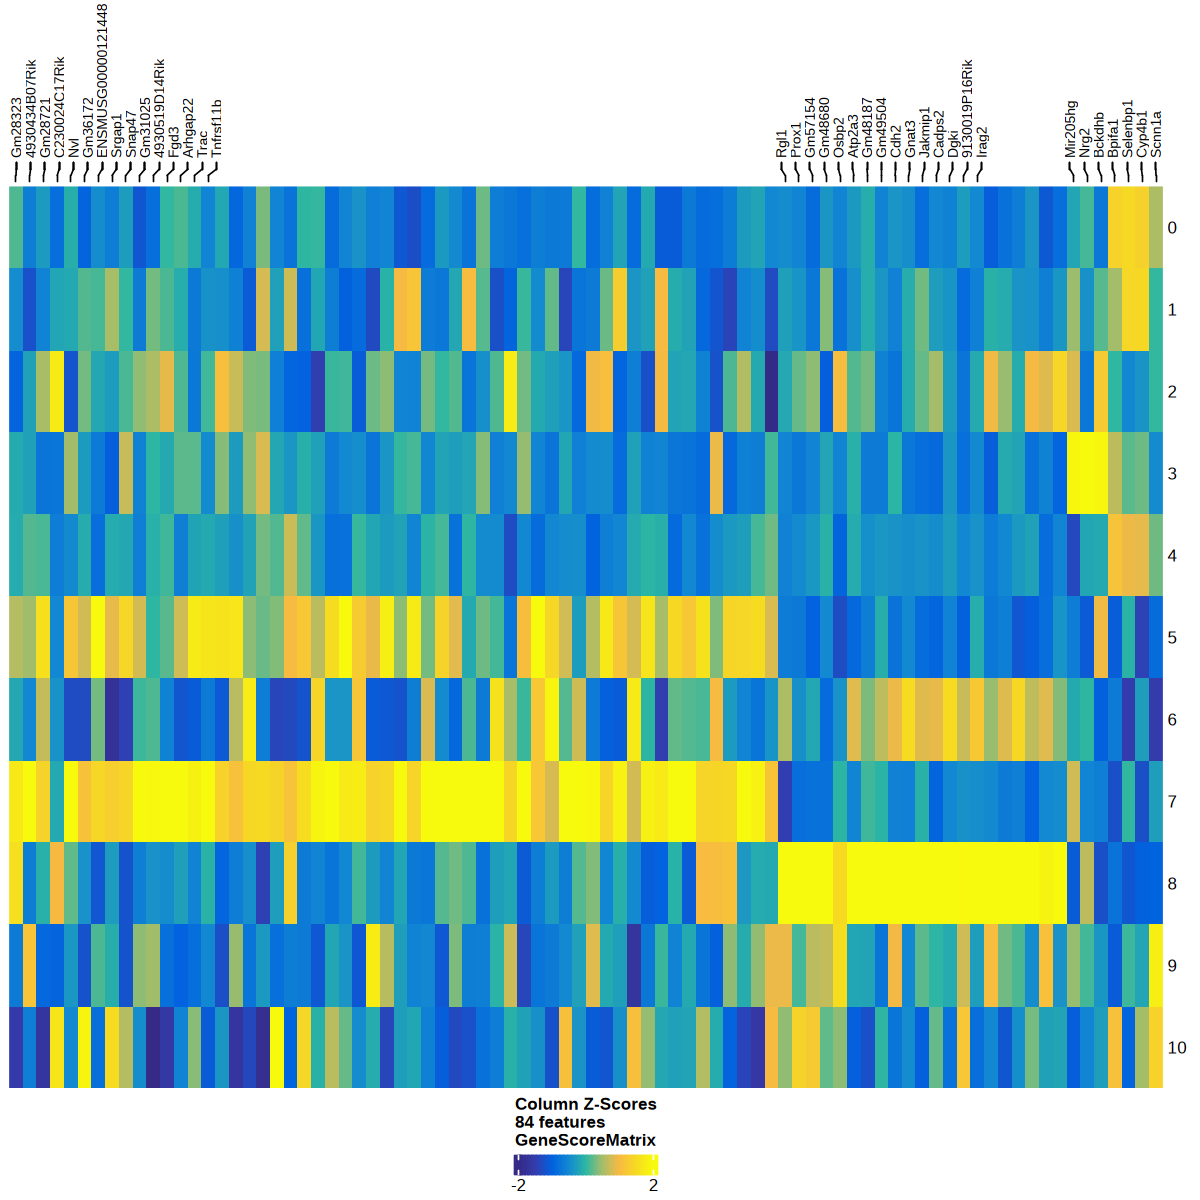

In [16]:
options(repr.plot.height = 10, repr.plot.width = 10)
ComplexHeatmap::draw(heatmapGS, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [ ]:
proj <- addImputeWeights(proj, dimsToUse = 2:15, scaleDims = TRUE)

In [ ]:
markerGenes  <- c(
    "Aqp3",  # NK cells
    "Scgb1a1",  # Club cells
    "Foxj1"  # Ciliated cells
    )

In [ ]:
p <- plotEmbedding(
    ArchRProj = proj, 
    colorBy = "GeneScoreMatrix", 
    name = markerGenes, 
    embedding = "umap",
    quantCut = c(0.01, 0.95),
    imputeWeights = NULL
)

In [ ]:
options(repr.plot.height = 10, repr.plot.width = 10)
print(p$Aqp3)

In [ ]:
p <- plotBrowserTrack(
    ArchRProj = proj, 
    groupBy = "Clusters", 
    geneSymbol = markerGenes, 
    upstream = 10000,
    downstream = 10000
)

In [ ]:
grid::grid.newpage()
grid::grid.draw(p$Aqp3)

In [ ]:
grid::grid.newpage()
grid::grid.draw(p$Scgb1a1)

In [ ]:
grid::grid.newpage()
grid::grid.draw(p$Foxj1)

In [ ]:
## Save data
saveArchRProject(ArchRProj = proj)

In [ ]:
saveRDS(markersGS, file = file.path(out_dir, "markersGS.rds"))

In [ ]:
## Session information
sessionInfo()